# Here i train my model to predict the price 

In [4]:
import pandas as pd 
import numpy as np

In [5]:
df = pd.read_csv("data.csv")

In [6]:
df.head()


,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,0.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,1.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,0.0,High,Mid Floor


In [7]:
df.shape

(3554, 13)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3554 non-null   str    
 1   sector           3554 non-null   str    
 2   price            3554 non-null   float64
 3   bedRoom          3554 non-null   float64
 4   bathroom         3554 non-null   float64
 5   balcony          3554 non-null   str    
 6   agePossession    3554 non-null   str    
 7   built_up_area    3554 non-null   float64
 8   servant room     3554 non-null   float64
 9   store room       3554 non-null   float64
 10  furnishing_type  3554 non-null   float64
 11  luxury_category  3554 non-null   str    
 12  floor_category   3554 non-null   str    
dtypes: float64(7), str(6)
memory usage: 507.3 KB


In [9]:
df["furnishing_type"].value_counts()

furnishing_type
0.0    2349
1.0    1018
2.0     187
Name: count, dtype: int64

In [10]:
df['furnishing_type'] = df['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [11]:
X = df.drop(columns=['price'])
y = df['price']

In [12]:
y = np.log1p(y)

In [82]:
import category_encoders as ce
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error,f1_score,accuracy_score

In [26]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

we apply tageted encoding

In [14]:
import category_encoders as ce

columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [15]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [16]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='r2')

In [17]:
scores.mean(),scores.std()

(np.float64(0.8295219182255362), np.float64(0.018384463379122834))

In [18]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

In [28]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [29]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [30]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [31]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.900469,0.448344
10,xgboost,0.900016,0.456596
5,random forest,0.901116,0.460972
7,gradient boosting,0.889234,0.506682
4,decision tree,0.828972,0.544472
9,mlp,0.849587,0.587987
8,adaboost,0.817231,0.680760
0,linear_reg,0.829522,0.713011
2,ridge,0.829536,0.713523
1,svr,0.782917,0.818851


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [ ]:
param_grid = {
    'regressor__n_estimators': [950, 996, 1050],
    'regressor__max_depth': [None, 40],
    'regressor__max_features': [0.65, 0.7, 0.75],
    'regressor__min_samples_split': [2, 3, 4],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__bootstrap': [False]
}

In [45]:
param_grid2 = {
    'regressor__n_estimators': [900, 950, 996, 1050, 1100],
    'regressor__max_depth': [None, 30, 40],
    'regressor__max_features': [0.6, 0.65, 0.7, 0.75, 0.8],
    'regressor__min_samples_split': [2, 3, 4],
    'regressor__min_samples_leaf': [1, 2],
}

In [33]:
param_dist = {
    'regressor__n_estimators': randint(100, 1000),
    'regressor__max_depth': [None, 10, 20, 30, 40, 50],
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'regressor__bootstrap': [True, False],
    'regressor__max_samples': [0.5, 0.7, 0.9, None]
}

In [137]:
columns_to_encode = ['property_type', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(n_estimators=945,n_jobs=-1,random_state=42))
])

kfold = KFold(n_splits=8, shuffle=True, random_state=42)



In [146]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['property_type','sector','bedRoom',...,'furnishing_type', 'luxury_category','floor_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed

In [147]:
y_pred = pipeline.predict(X_test)

In [148]:
r2_score(y_test,y_pred)
# mean_absolute_error(y_pred,y_test)

0.9137861917075392

In [87]:
mean_squared_error(y_test,y_pred)

0.027290692049108164

In [141]:
import pickle

with open("ETRmodel.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [142]:

with open("df.pkl", "wb") as f:
    pickle.dump(X, f)

In [91]:
pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 4.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 4.5 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 5.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.2 MB/s  0:00:01
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.w

Matplotlib is building the font cache; this may take a moment.


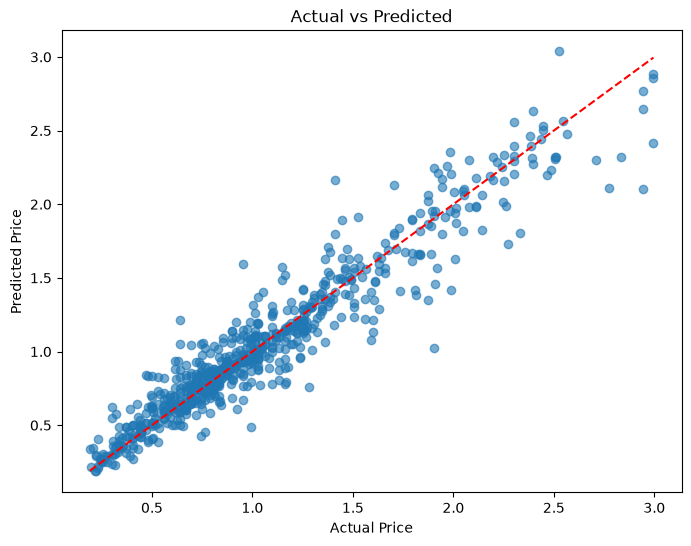

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

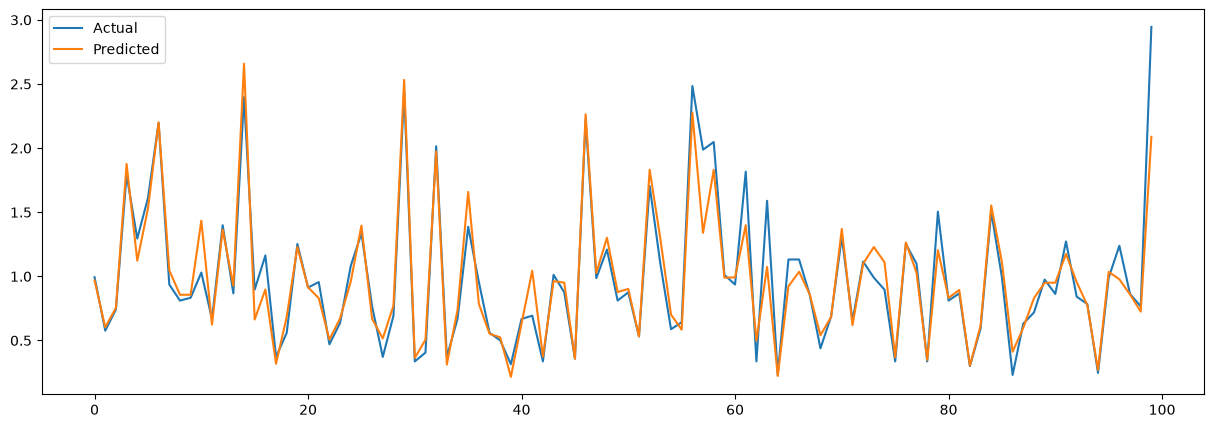

In [101]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()

plt.show()

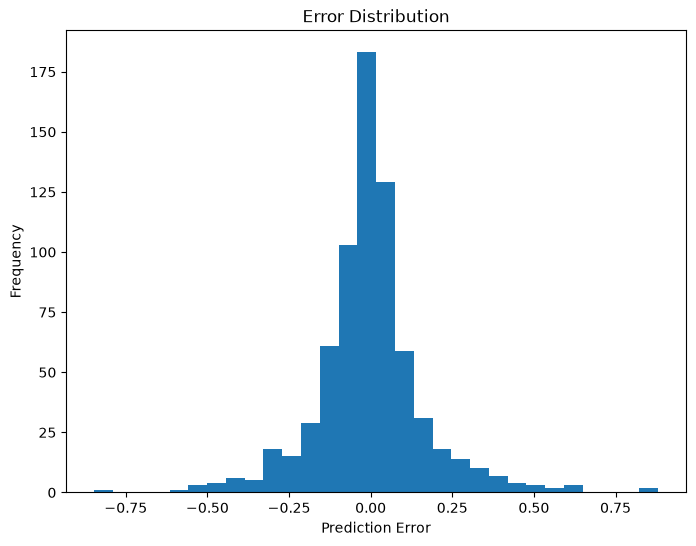

In [102]:
plt.figure(figsize=(8,6))

plt.hist(y_test - y_pred, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Error Distribution")

plt.show()

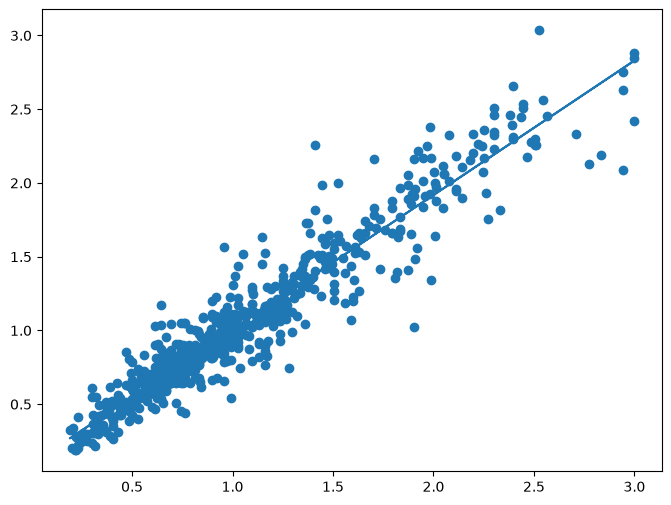

In [ ]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

m, b = np.polyfit(y_test, y_pred, 1)

plt.plot(y_test, m*y_test + b)

plt.show()

In [52]:
search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid2,
    cv=kfold, 
    scoring='r2',
    n_jobs=-1,
    verbose=4
    )

In [53]:
search.fit(X_train, y_train)

Fitting 8 folds for each of 450 candidates, totalling 3600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [None, 30, ...], 'regressor__max_features': [0.6, 0.65, ...], 'regressor__min_samples_leaf': [1, 2], 'regressor__min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` para

In [70]:
s_pred = search.predict(X_test)
y_pred
y_test

299     0.993252
2240    0.576613
2384    0.741937
3473    1.791759
2614    1.294727
          ...   
1052    0.536493
3275    0.955511
1108    1.029619
787     0.641854
2633    1.098612
Name: price, Length: 711, dtype: float64

In [88]:
r2_score(y_test,s_pred)
# mean_absolute_error(s_pred,y_test)


0.9119300066650143

In [79]:
mean_squared_error(s_pred,y_test)

0.027537958565816246

In [54]:
search.best_params_

{'regressor__max_depth': 30,
 'regressor__max_features': 0.75,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 4,
 'regressor__n_estimators': 900}

In [55]:
search.best_score_

np.float64(0.8842368908063953)

In [56]:
R_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100,          # 100 random combinations
    scoring='r2',
    cv=10,
    verbose=4,
    random_state=42,
    n_jobs=-1
)

In [149]:
R_search.fit(X, y)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


PicklingError: Could not pickle the task to send it to the workers.

In [58]:
R_search.best_params_

{'regressor__bootstrap': False,
 'regressor__max_depth': None,
 'regressor__max_features': 0.7,
 'regressor__max_samples': None,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 3,
 'regressor__n_estimators': 996}

In [59]:
R_search.best_score_

np.float64(0.882185976956739)

In [71]:
R_pred = R_search.predict(X_test)

In [90]:
r2_score(y_test,R_pred)
# mean_absolute_error(s_pred,y_test)

0.9119812683640501

In [89]:
mean_squared_error(y_test,R_pred)

0.027521929922113584

In [76]:
mean_absolute_error(R_pred,y_test)

0.11104362867622791